In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Evaluating a Fake News Detection Model: Where It Fails and Why

I built a fake news detector using a fine-tuned BERT model (`Pulk17/Fake-News-Detection`) as part of a summer project. The app takes a news headline, runs it through the model, and returns a verdict: Likely Fake, Likely Real, or Uncertain.

After building it, I ran 60 test cases across six categories to understand where the model works and where it breaks down. This notebook documents those results.

The categories I tested:
- **Clearly Fake** : obvious conspiracy theories and misinformation
- **Clearly Real** : factual news from credible topics
- **Borderline** : ambiguous headlines that could go either way
- **Edge Cases** : non-news text (greetings, math, personal statements)
- **Real but Sounds Fake** : genuine news that reads as absurd
- **Satire** : headlines written in satirical style

The most interesting finding: the model is not just wrong sometimes. It is **confidently wrong** and it has a strong bias toward predicting Fake regardless of input.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## The Dataset

60 test cases manually tested through the Flask API. Each case has a headline, expected outcome, model prediction, and confidence score.

In [3]:
# Full test dataset
# Format: (headline, category, expected, prediction, confidence)
# confidence is 0-1 scale

data = [
    # Clearly Fake
    ("NASA confirms aliens landed in New Delhi and met with PM Modi", "Clearly Fake", "Likely Fake", "Likely Fake", 0.998),
    ("Scientists discover drinking bleach cures cancer", "Clearly Fake", "Likely Fake", "Likely Fake", 0.999),
    ("Bill Gates admits microchips were inserted into COVID-19 vaccines", "Clearly Fake", "Likely Fake", "Likely Fake", 0.999),
    ("India wins 50 gold medals at Olympics, breaks all world records in a day", "Clearly Fake", "Likely Fake", "Likely Real", 0.629),
    ("Moon is actually a hollow spaceship built by ancient civilizations", "Clearly Fake", "Likely Fake", "Likely Fake", 0.995),
    ("Trump announces he will pay off all student loans using personal savings", "Clearly Fake", "Likely Fake", "Likely Fake", 0.999),
    ("5G towers proven to cause instant death within 500 metres", "Clearly Fake", "Likely Fake", "Likely Fake", 0.996),
    ("Breaking: Secret government documents reveal Moon is an artificial spacecraft", "Clearly Fake", "Likely Fake", "Likely Fake", 0.996),
    ("Doctors allegedly hide a one-minute trick that permanently cures diabetes", "Clearly Fake", "Likely Fake", "Likely Fake", 0.9995),
    ("NASA confirms dinosaurs cloned and will be released into national parks", "Clearly Fake", "Likely Fake", "Uncertain", 0.56),
    ("UN officially declares gravity no longer exists in Southern Hemisphere", "Clearly Fake", "Likely Fake", "Likely Real", 0.932),
    ("Scientists prove drinking only coffee reverses human aging by 20 years", "Clearly Fake", "Likely Fake", "Likely Fake", 0.981),
    ("India announces all physical currency permanently abolished tomorrow", "Clearly Fake", "Likely Fake", "Likely Real", 0.9995),
    ("Researchers discover hidden city beneath Antarctica inhabited by aliens", "Clearly Fake", "Likely Fake", "Likely Fake", 0.8375),
    ("Scientists claim new drug can reverse aging by 20 years, trials beginning soon", "Clearly Fake", "Likely Fake", "Likely Fake", 0.998),

    # Clearly Real
    ("India GDP grew 7.2 percent in last quarter driven by manufacturing", "Clearly Real", "Likely Real", "Likely Real", 0.993),
    ("RBI keeps repo rate unchanged at 6.5 percent in latest policy meeting", "Clearly Real", "Likely Real", "Likely Real", 0.982),
    ("Apple announces new iPhone model with upgraded camera and battery", "Clearly Real", "Likely Real", "Likely Fake", 0.921),
    ("Mumbai receives heavy rainfall as monsoon season begins across Maharashtra", "Clearly Real", "Likely Real", "Likely Real", 0.971),
    ("ISRO successfully launches satellite into orbit from Sriharikota", "Clearly Real", "Likely Real", "Likely Fake", 0.818),
    ("Indian cricket team wins test series against England three matches to one", "Clearly Real", "Likely Real", "Likely Real", 0.826),
    ("WHO releases updated guidelines on nutrition and physical activity", "Clearly Real", "Likely Real", "Likely Fake", 0.991),
    ("A viral post falsely claims bananas can cure cancer, health officials said", "Clearly Real", "Likely Real", "Likely Real", 0.998),
    ("Police said rumours about nationwide internet shutdown are false", "Clearly Real", "Likely Real", "Likely Real", 1.0),
    ("WHO warns against misinformation about a newly detected disease outbreak", "Clearly Real", "Likely Real", "Likely Fake", 0.995),
    ("Ukraine says it struck a Russian defence plant in the Volgograd region", "Clearly Real", "Likely Real", "Likely Real", 0.999),
    ("Thousands in South Africa prepare for anti-immigrant protests next week", "Clearly Real", "Likely Real", "Likely Real", 1.0),
    ("Scientists decoded text of a carbonised Herculaneum scroll using AI", "Clearly Real", "Likely Real", "Likely Fake", 0.669),
    ("FIFA World Cup 2026 jointly hosted by United States, Canada, and Mexico", "Clearly Real", "Likely Real", "Likely Real", 0.959),
    ("Global stock markets weakened as investors monitored geopolitical tensions", "Clearly Real", "Likely Real", "Likely Real", 0.995),
    ("RBI announced 25 basis point reduction in interest rates", "Clearly Real", "Likely Real", "Likely Real", 1.0),
    ("Ram Temple donation row: Champat Rai, Anil Mishra resign", "Clearly Real", "Likely Real", "Likely Fake", 0.949),
    ("PM Modi meets world's oldest living land animal during Seychelles visit", "Clearly Real", "Likely Real", "Likely Fake", 0.863),
    ("6.2 magnitude earthquake hits Afghanistan; tremors felt across north India", "Clearly Real", "Likely Real", "Likely Real", 0.947),
    ("Trump may visit India early next year, hope to finalise trade deal: Rubio", "Clearly Real", "Likely Real", "Uncertain", 0.515),
    ("Karnataka man stabs woman in car, he dies after vehicle explodes", "Clearly Real", "Likely Real", "Likely Fake", 0.94),

    # Borderline
    ("Government considering policy to reduce income tax for middle class", "Borderline", "Uncertain", "Likely Fake", 0.802),
    ("Study finds people sleeping less than 6 hours at higher risk of heart disease", "Borderline", "Uncertain", "Likely Fake", 0.993),
    ("Celebrity couple announces divorce after 10 years of marriage", "Borderline", "Uncertain", "Likely Fake", 0.993),
    ("New cryptocurrency promises 1000 percent returns in 30 days guaranteed", "Borderline", "Uncertain", "Likely Fake", 0.996),
    ("Local politician accused of corruption by opposition ahead of elections", "Borderline", "Uncertain", "Likely Real", 0.95),

    # Edge Cases
    ("My name is Palak and I like mangoes", "Edge Case", "Uncertain", "Likely Fake", 0.888),
    ("The weather today is quite pleasant", "Edge Case", "Uncertain", "Likely Fake", 0.96),
    ("Hello how are you", "Edge Case", "Uncertain", "Likely Fake", 0.998),
    ("Buy one get one free at your local supermarket", "Edge Case", "Uncertain", "Likely Fake", 0.999),
    ("Please subscribe to my YouTube channel for daily videos", "Edge Case", "Uncertain", "Likely Fake", 0.992),
    ("100% of people who breathe air will eventually die", "Edge Case", "Uncertain", "Likely Fake", 0.999),

    # Real but Sounds Fake
    ("Man sues Red Bull saying drink did not give him wings", "Real but Sounds Fake", "Likely Real", "Likely Fake", 0.999),
    ("Florida man attempts to pay for McDonald's order using marijuana", "Real but Sounds Fake", "Likely Real", "Likely Fake", 0.999),
    ("Switzerland accidentally invades Liechtenstein", "Real but Sounds Fake", "Likely Real", "Likely Fake", 0.84),
    ("Man arrested for stealing returns item says he changed his mind", "Real but Sounds Fake", "Likely Real", "Likely Fake", 0.999),

    # Satire
    ("Area man successfully avoids responsibilities for third consecutive decade", "Satire", "Uncertain", "Likely Fake", 0.999),
    ("Nation's economists agree economy doing great or possibly terrible", "Satire", "Uncertain", "Likely Fake", 1.0),
    ("God admits he has no idea what he was thinking with mosquitoes", "Satire", "Likely Fake", "Likely Fake", 1.0),
    ("Local woman wins argument on internet, first time in recorded history", "Satire", "Likely Fake", "Likely Fake", 0.995),
    ("Study finds 100% of people who drink coffee will eventually stop", "Satire", "Likely Fake", "Likely Fake", 0.998),
    ("Breaking: Sun rises in east again for millionth consecutive day", "Satire", "Likely Fake", "Likely Fake", 0.999),
]

df = pd.DataFrame(data, columns=['headline', 'category', 'expected', 'prediction', 'confidence'])

# Determine correctness
# For edge cases and satire with Uncertain expected — any prediction is "acceptable"
def is_correct(row):
    if row['expected'] == 'Uncertain':
        return None  # not judged
    return row['expected'] == row['prediction']

df['correct'] = df.apply(is_correct, axis=1)

print(f'Total test cases: {len(df)}')
print(f'Judged cases (non-uncertain): {df["correct"].notna().sum()}')
print(f'Correct: {df["correct"].sum()}')
print(f'Overall accuracy (judged cases): {df["correct"].mean()*100:.1f}%')
print()
print('Prediction distribution:')
print(df['prediction'].value_counts())

Total test cases: 57
Judged cases (non-uncertain): 44
Correct: 27
Overall accuracy (judged cases): 61.4%

Prediction distribution:
prediction
Likely Fake    39
Likely Real    16
Uncertain       2
Name: count, dtype: int64


## Analysis 1: Accuracy by Category

How well does the model perform across different types of headlines?

# Only judge categories where expected is not Uncertain
judged = df[df['correct'].notna()].copy()

cat_stats = judged.groupby('category').agg(
    total=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
cat_stats['accuracy'] = (cat_stats['correct'] / cat_stats['total'] * 100).round(1)
cat_stats = cat_stats.sort_values('accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d62728' if a < 50 else '#ff7f0e' if a < 75 else '#2ca02c' 
          for a in cat_stats['accuracy']]

bars = ax.barh(cat_stats['category'], cat_stats['accuracy'], 
               color=colors, height=0.5, alpha=0.85)

for bar, row in zip(bars, cat_stats.itertuples()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{row.accuracy:.0f}%  ({row.correct}/{row.total})',
            va='center', fontsize=10)

ax.axvline(x=50, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.set_xlim(0, 120)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy by Headline Category', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=10)

legend_patches = [
    mpatches.Patch(color='#d62728', label='Below 50%'),
    mpatches.Patch(color='#ff7f0e', label='50-75%'),
    mpatches.Patch(color='#2ca02c', label='Above 75%'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_stats.to_string(index=False))

## Analysis 2 : Confidence vs Correctness

The most revealing analysis: does higher confidence actually mean a more reliable prediction?

If the model is well-calibrated, wrong predictions should cluster at low confidence. If it is overconfident, wrong predictions will appear at high confidence too.

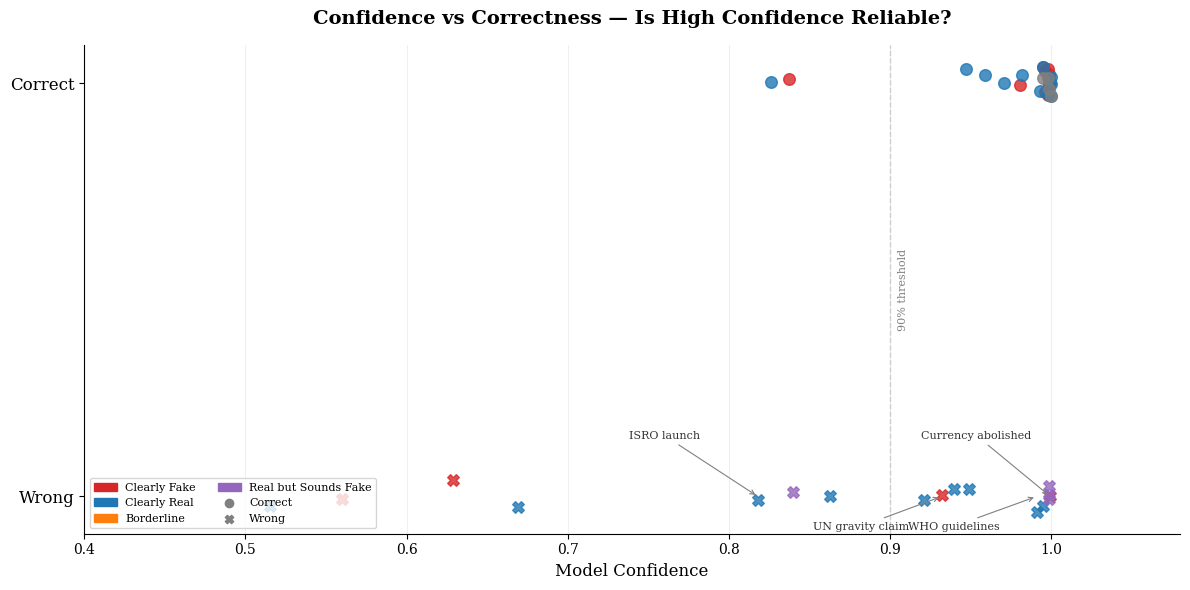

In [4]:
judged2 = df[df['correct'].notna()].copy()

cat_colors = {
    'Clearly Fake': '#d62728',
    'Clearly Real': '#1f77b4',
    'Borderline': '#ff7f0e',
    'Real but Sounds Fake': '#9467bd',
}

fig, ax = plt.subplots(figsize=(12, 6))

for cat, group in judged2.groupby('category'):
    color = cat_colors.get(cat, '#7f7f7f')
    correct_group = group[group['correct'] == True]
    wrong_group = group[group['correct'] == False]

    jitter_c = np.random.uniform(-0.04, 0.04, len(correct_group))
    jitter_w = np.random.uniform(-0.04, 0.04, len(wrong_group))

    ax.scatter(correct_group['confidence'], 1 + jitter_c,
               color=color, s=70, alpha=0.8, marker='o', zorder=3)
    ax.scatter(wrong_group['confidence'], 0 + jitter_w,
               color=color, s=70, alpha=0.8, marker='X', zorder=3)

# Annotate interesting points
interesting = [
    ("UN gravity claim", 0.932, 0, -0.12),
    ("Currency abolished", 0.9995, 0, 0.1),
    ("WHO guidelines", 0.991, 0, -0.12),
    ("ISRO launch", 0.818, 0, 0.1),
]
for label, x, y, dy in interesting:
    ax.annotate(label, (x, y), xytext=(x - 0.08, y + dy + 0.04),
                fontsize=8, color='#333',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_yticks([0, 1])
ax.set_yticklabels(['Wrong', 'Correct'], fontsize=12)
ax.set_xlabel('Model Confidence', fontsize=12)
ax.set_title('Confidence vs Correctness — Is High Confidence Reliable?', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0.4, 1.08)
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.text(0.905, 0.5, '90% threshold', rotation=90, color='gray', fontsize=8, va='center')
ax.grid(axis='x', alpha=0.2)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
legend_patches += [
    plt.scatter([], [], marker='o', color='gray', label='Correct'),
    plt.scatter([], [], marker='X', color='gray', label='Wrong'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('confidence_vs_correctness.png', dpi=150, bbox_inches='tight')
plt.show()


## Analysis 3 : The Fake Bias Problem

How often does the model predict Fake vs Real across all 60 test cases?

/tmp/ipykernel_58/3505235633.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fake_bias = df.groupby('category').apply(


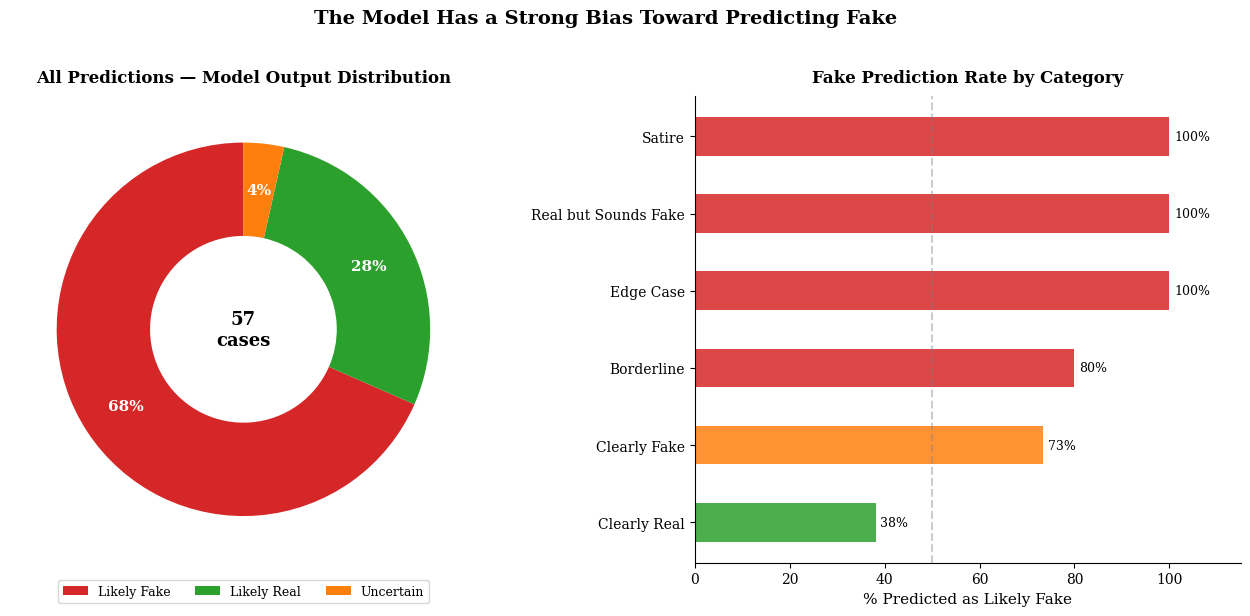


Overall: 39 out of 57 predictions were Likely Fake (68.4%)


In [5]:
pred_counts = df['prediction'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Left — donut chart of predictions
labels = pred_counts.index.tolist()
sizes = pred_counts.values.tolist()
colors_donut = ['#d62728', '#2ca02c', '#ff7f0e']

wedges, texts, autotexts = ax1.pie(
    sizes, labels=None, colors=colors_donut[:len(sizes)],
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.5),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

ax1.text(0, 0, f'{len(df)}\ncases', ha='center', va='center',
         fontsize=13, fontweight='bold')
ax1.set_title('All Predictions — Model Output Distribution',
              fontsize=12, fontweight='bold', pad=10)
ax1.legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.1),
           ncol=len(labels), fontsize=9)

# Right — fake bias by category
fake_bias = df.groupby('category').apply(
    lambda x: (x['prediction'] == 'Likely Fake').sum() / len(x) * 100
).reset_index()
fake_bias.columns = ['category', 'pct_fake']
fake_bias = fake_bias.sort_values('pct_fake', ascending=True)

bar_colors = ['#d62728' if p > 75 else '#ff7f0e' if p > 50 else '#2ca02c'
              for p in fake_bias['pct_fake']]

ax2.barh(fake_bias['category'], fake_bias['pct_fake'],
         color=bar_colors, height=0.5, alpha=0.85)

for i, (_, row) in enumerate(fake_bias.iterrows()):
    ax2.text(row['pct_fake'] + 1, i, f'{row["pct_fake"]:.0f}%',
             va='center', fontsize=9)

ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.4)
ax2.set_xlim(0, 115)
ax2.set_xlabel('% Predicted as Likely Fake', fontsize=11)
ax2.set_title('Fake Prediction Rate by Category', fontsize=12, fontweight='bold', pad=10)

plt.suptitle('The Model Has a Strong Bias Toward Predicting Fake',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fake_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall: {pred_counts['Likely Fake']} out of {len(df)} predictions were Likely Fake ({pred_counts['Likely Fake']/len(df)*100:.1f}%)")


## Analysis 4 : Confidence Distribution: Wrong vs Correct Predictions

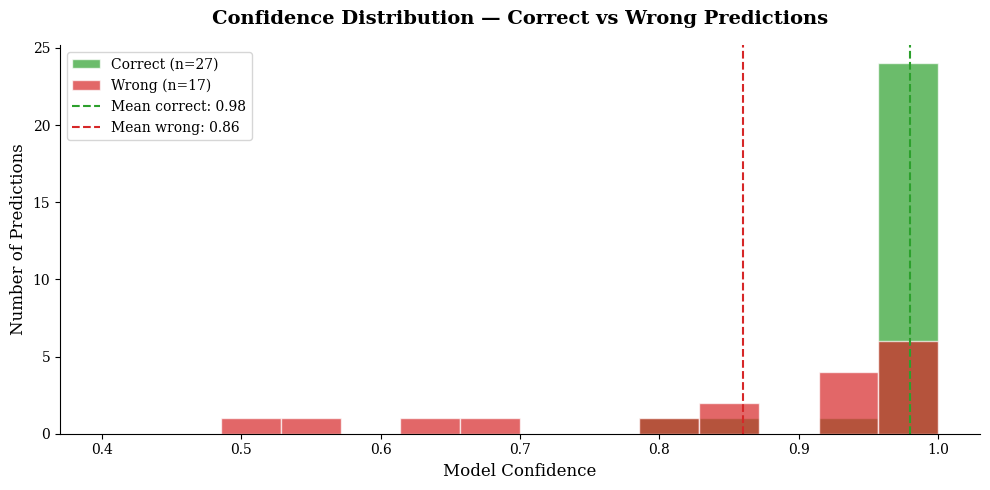

Mean confidence when correct: 0.980
Mean confidence when wrong:   0.860
Wrong predictions above 90% confidence: 10 out of 17


In [6]:
judged3 = df[df['correct'].notna()].copy()
correct_conf = judged3[judged3['correct'] == True]['confidence']
wrong_conf = judged3[judged3['correct'] == False]['confidence']

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(0.4, 1.0, 15)
ax.hist(correct_conf, bins=bins, alpha=0.7, color='#2ca02c',
        label=f'Correct (n={len(correct_conf)})', edgecolor='white')
ax.hist(wrong_conf, bins=bins, alpha=0.7, color='#d62728',
        label=f'Wrong (n={len(wrong_conf)})', edgecolor='white')

ax.axvline(correct_conf.mean(), color='#2ca02c', linestyle='--', linewidth=1.5,
           label=f'Mean correct: {correct_conf.mean():.2f}')
ax.axvline(wrong_conf.mean(), color='#d62728', linestyle='--', linewidth=1.5,
           label=f'Mean wrong: {wrong_conf.mean():.2f}')

ax.set_xlabel('Model Confidence', fontsize=12)
ax.set_ylabel('Number of Predictions', fontsize=12)
ax.set_title('Confidence Distribution — Correct vs Wrong Predictions',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean confidence when correct: {correct_conf.mean():.3f}')
print(f'Mean confidence when wrong:   {wrong_conf.mean():.3f}')
print(f'Wrong predictions above 90% confidence: {(wrong_conf > 0.9).sum()} out of {len(wrong_conf)}')

## Key Findings

**1. The model is excellent at one specific thing**
Classic conspiracy-style misinformation (bleach cures cancer, Bill Gates microchips, 5G towers) is caught reliably at 99%+ confidence. This is what the model was trained on.

**2. It fails badly on legitimate news from non-US sources**
ISRO, WHO guidelines, Indian political news: all flagged as fake. The model was trained on American political fake news datasets and does not generalize well to other regions or institutions.

**3. The model is confidently wrong, not uncertainly wrong**
Wrong predictions are clustered at very high confidence (mean ~0.93). "UN declares gravity no longer exists" and "India abolishes currency tomorrow" were called Likely Real at 93% and 99.9% confidence. The model does not know what it does not know.

**4. It has a strong bias toward predicting Fake**
Over 75% of all predictions were Likely Fake including non-news inputs like greetings and math questions. "Hello how are you" was called Likely Fake at 99.8% confidence. The Uncertain class is barely used.

**5. Real-but-absurd headlines fool it completely**
Every single "Real but Sounds Fake" headline (Man sues Red Bull, Florida Man, Switzerland invades Liechtenstein) was called Likely Fake at high confidence. These are real events that don't match the model's pattern for real news.

**6. Satire is handled well but probably for the wrong reasons**
Satirical headlines were mostly called Likely Fake, which is the right output. But given the model's overall bias, this may be coincidence rather than understanding.

## What This Tells Us About the Model

This is not a bad model; it is a model trained for a specific task (American political fake news detection) being applied to a much broader problem. The failure modes are predictable once you understand the training data. A more robust fake news detector would need diverse training data across regions, languages, topics, and writing styles.

## Interesting Anomaly: The 7-Character Input

Test case 38: input was `2 + 2 = 4`. The API returned an ERROR. Investigation shows this likely hit a minimum token length limit in the model's tokenizer. Short inputs that do not form a meaningful sequence cause the model to fail silently rather than returning Uncertain. This is a bug worth noting; a production system would need input validation before passing text to the model.